In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

# 'RELIANCE.NS' targets Reliance on the National Stock Exchange of India
ticker = "RELIANCE.NS"

print(f"Downloading data for {ticker}...")
data = yf.download(ticker, start="2021-05-18", end="2026-05-18")

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

print("\n--- First 5 Rows of Data ---")
print(data.head())
print(data.tail())

print("---Info---")
print(data.info())

[*********************100%***********************]  1 of 1 completed


--- First 5 Rows of Data ---
Price            Close        High         Low        Open    Volume
Date                                                                
2021-05-18  897.250183  903.862393  890.276896  894.113365  12064918
2021-05-19  901.357361  910.113470  890.051207  893.661920  16317002
2021-05-20  896.099182  907.608468  894.113287  901.740977  11422532
2021-05-21  903.839783  907.021728  896.370037  899.078087  10785605
2021-05-24  896.212097  907.112107  894.564716  906.299639   8551760
Price             Close         High          Low         Open    Volume
Date                                                                    
2026-05-11  1381.811035  1421.427912  1375.639618  1413.464731  15261787
2026-05-12  1357.722412  1387.086643  1354.039489  1385.593547  24357500
2026-05-13  1352.546387  1366.083771  1346.175817  1355.134396  13797989
2026-05-14  1355.532593  1371.657986  1352.148216  1358.916848  17303059
2026-05-15  1330.249512  1358.518831  1323.082575

In [2]:
# 1. Use .squeeze() for removig the unnecessary dimensional vectors
adj_close = data['Close'].squeeze()

print("-----------Summary Statistics---------")
print(adj_close.describe())

# 2 Check for missing data
print(data.isnull().sum())

# 3. Calculate variance (this will now be a single number scalar!)
variance = adj_close.var()
print(f"\nAsset Variance: {variance:.2f}")

-----------Summary Statistics---------
count    1237.000000
mean     1251.361898
std       161.689597
min       886.056824
25%      1127.037598
50%      1223.059570
75%      1402.316284
max      1584.971802
Name: Close, dtype: float64
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Asset Variance: 26143.53


In [3]:
# Find the exact dates of the highest and lowest prices
highest_price_date = adj_close.idxmax()
lowest_price_date = adj_close.idxmin()

# Find the exact prices on those dates
highest_price = adj_close.max()
lowest_price = adj_close.min()

print(f"5-Year High: INR {highest_price:.2f} on {highest_price_date.strftime('%Y-%m-%d')}")
print(f"5-Year Low:  INR {lowest_price:.2f} on {lowest_price_date.strftime('%Y-%m-%d')}")

mean_val = adj_close.mean()
median_val = adj_close.median()

print(f"\nMean Price: INR {mean_val:.2f}")
print(f"Median Price: INR {median_val:.2f}")

if mean_val > median_val:
    print("Insight: The data is positively skewed. Heavy upward rallies are pulling the average up.")
else:
    print("Insight: The data is negatively skewed or symmetric.")

5-Year High: INR 1584.97 on 2026-01-02
5-Year Low:  INR 886.06 on 2021-05-25

Mean Price: INR 1251.36
Median Price: INR 1223.06
Insight: The data is positively skewed. Heavy upward rallies are pulling the average up.


In [4]:
# 1. Calculate percentage change row-by-row on our squeezed Close prices
daily_returns = adj_close.pct_change()

print("--- Raw Daily Returns Table ---")
print(daily_returns.head())

# 2. THE PITFALL: Look at the very first row. It will say 'NaN' 
# Why? Because the first day has no "yesterday" to calculate a change from!
# We must clean this using .dropna() or our future math will break.

clean_returns = daily_returns.dropna()

print("\n--- Cleaned Summary Statistics for Returns ---")
print(clean_returns.describe())

# 3. Scale up the metrics to make them human-readable
print(f"\nMaximum Single-Day Gain: {clean_returns.max() * 100:.2f}%")
print(f"Maximum Single-Day Loss: {clean_returns.min() * 100:.2f}%")

--- Raw Daily Returns Table ---
Date
2021-05-18         NaN
2021-05-19    0.004578
2021-05-20   -0.005834
2021-05-21    0.008638
2021-05-24   -0.008439
Name: Close, dtype: float64

--- Cleaned Summary Statistics for Returns ---
count    1236.000000
mean        0.000419
std         0.014173
min        -0.074851
25%        -0.007983
50%         0.000571
75%         0.007883
max         0.070192
Name: Close, dtype: float64

Maximum Single-Day Gain: 7.02%
Maximum Single-Day Loss: -7.49%


In [5]:
daily_volatility = clean_returns.std()
print(f"Standard deviation of eveeryday return: {daily_volatility * 100:.2f}%")

Standard deviation of eveeryday return: 1.42%


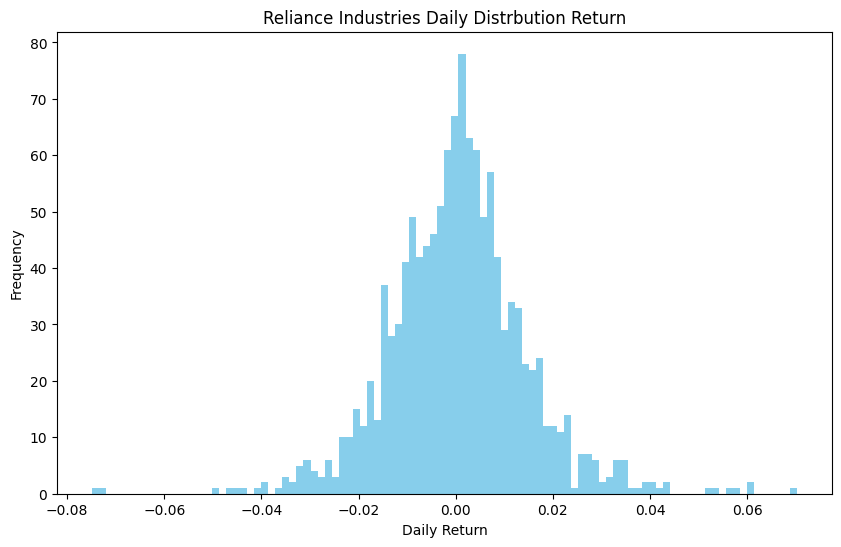

avr = 22.49


In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(clean_returns, bins=100 , color = 'skyblue')
plt.title("Reliance Industries Daily Distrbution Return")
plt.ylabel("Frequency")
plt.xlabel("Daily Return")
plt.show()

annualized_volatility_rate = daily_volatility*15.87
print(f"avr = {annualized_volatility_rate * 100:.2f}")

In [7]:
log_returns = np.log(adj_close) - np.log(adj_close.shift(1))
clean_log_returns = log_returns.dropna()

slice_start, slice_end = 5,10;

summed_log_return = clean_log_returns.iloc[slice_start:slice_end].sum()

price_start = adj_close.iloc[slice_start]
price_end = adj_close.iloc[slice_end]
direct_log_return = np.log(price_end / price_start)

skew = clean_log_returns.skew()
kurtosis = clean_log_returns.kurtosis()

print(f"Summed Daily Log Returns: {summed_log_return:.6f}")
print(f"Direct Period Log Return: {direct_log_return:.6f}")

print(f"Log Return Skewness     : {skew:.4f}")
print(f"Excess Kurtosis (Tails) : {kurtosis:.4f}")

if kurtosis > 0:
    print("Insight: The asset exhibits Leptokurtosis (Fat Tails).")
    print("Standard risk models will structurally underestimate the chance of a market crash.")

Summed Daily Log Returns: 0.099670
Direct Period Log Return: 0.099670
Log Return Skewness     : 0.0284
Excess Kurtosis (Tails) : 2.8244
Insight: The asset exhibits Leptokurtosis (Fat Tails).
Standard risk models will structurally underestimate the chance of a market crash.


In [8]:
# STEP 1: Calculate a 20-Day Rolling Mean (Simple Moving Average)
# TODO: Use .rolling() with a window of 20 and apply the mean function to adj_close.
# Save it into a new column inside your dataframe called data['SMA_20']
data['SMA_10'] = adj_close.rolling(window = 20).mean()


# STEP 2: Calculate a 20-Day Rolling Volatility (Standard Deviation)
# TODO: Use .rolling() with a window of 20 and apply the standard deviation (.std()) function.
# Save it into a new column called data['Rolling_Vol_20']
data['Rolling_Vol_10'] = adj_close.rolling(window=20).std()


print("--- 20-Day Rolling Window Framework ---")
# This prints out a slice where the rolling windows have enough data to compute
print(data[['Close', 'SMA_10', 'Rolling_Vol_10']].dropna().head(10))


# STEP 3: Fetch the latest data point for our trading signal
# We use .iloc[-1] to grab the very last row (today's live market data)
latest_row = data.iloc[-1]
current_price = latest_row['Close'].squeeze()
current_sma = latest_row['SMA_10'].squeeze()


print("\n=========================================")
print("       📡 ALGORITHMIC TREND SIGNAL       ")
print("=========================================")
print(f"Current Closing Price : INR {current_price:.2f}")
print(f"20-Day Moving Average : INR {current_sma:.2f}")
print("-----------------------------------------")


# STEP 4: Write the Conditional Trading Logic
# TODO: Write an if/else block:
# - IF current_price is greater than current_sma: Print a BULLISH momentum message.
# - ELSE: Print a BEARISH momentum message.
# WRITE YOUR CODE HERE

if(current_price>current_sma):
    print("Signal: Bullish Momentum-> The current price is higher than the average of the previous trend:")
else:
    print("Signal: Bearish Momentum-> The current price is lower than the average of the previous trend ")


print("=========================================")

--- 20-Day Rolling Window Framework ---
Price             Close      SMA_10  Rolling_Vol_10
Date                                               
2021-06-14  1016.755371  951.589578       49.346779
2021-06-15  1019.065308  957.680334       49.802370
2021-06-16  1001.673218  962.696127       48.874263
2021-06-17  1003.507507  968.066544       47.037928
2021-06-18  1008.036682  973.276389       45.287649
2021-06-21  1013.290527  979.130310       42.268136
2021-06-22  1008.082031  985.231570       36.545812
2021-06-23   998.842529  990.715140       28.775532
2021-06-24   975.358704  994.887988       17.556032
2021-06-25   953.143127  995.271329       16.470471

       📡 ALGORITHMIC TREND SIGNAL       
Current Closing Price : INR 1330.25
20-Day Moving Average : INR 1385.43
-----------------------------------------
Signal: Bearish Momentum-> The current price is lower than the average of the previous trend 


In [9]:
df = data.copy().sort_index()
df['Signal'] = np.where(df['Close'] > df['SMA_10'], 1, -1)
df['Position'] = df['Signal'].shift(1)
df = df.dropna()
df.head()

Price,Close,High,Low,Open,Volume,SMA_10,Rolling_Vol_10,Signal,Position
Date,,,,,,,,,
2021-06-14,1016.755371,1022.801813,994.177384,1003.213143,20332436,951.589578,49.346779,1,-1.0
2021-06-15,1019.065308,1030.342951,1014.671990,1024.047444,15174215,957.680334,49.802370,1,1.0
2021-06-16,1001.673218,1017.729157,999.068938,1016.755420,10797349,962.696127,48.874263,1,1.0
2021-06-17,1003.507507,1012.271500,987.315715,996.419342,15745975,968.066544,47.037928,1,1.0
2021-06-18,1008.036682,1012.271504,989.331180,1007.968755,29369026,973.276389,45.287649,1,1.0


In [10]:
df['Market_Return'] = df['Close'].pct_change()
df['Strategy_Return'] = df['Market_Return'] * df['Position']

df['Baseline_Equity'] = (1 + df['Market_Return'].fillna(0)).cumprod()
df['Strategy_Equity'] = (1 + df['Strategy_Return'].fillna(0)).cumprod()
df.tail()

Price,Close,High,Low,Open,Volume,SMA_10,Rolling_Vol_10,Signal,Position,Market_Return,Strategy_Return,Baseline_Equity,Strategy_Equity
Date,,,,,,,,,,,,,
2026-05-11,1381.811035,1421.427912,1375.639618,1413.464731,15261787,1382.771643,46.683995,-1,1.0,-0.032748,-0.032748,1.359040,0.803531
2026-05-12,1357.722412,1387.086643,1354.039489,1385.593547,24357500,1385.205389,43.819164,-1,-1.0,-0.017433,0.017433,1.335348,0.817539
2026-05-13,1352.546387,1366.083771,1346.175817,1355.134396,13797989,1385.937006,43.104340,-1,-1.0,-0.003812,0.003812,1.330257,0.820655
2026-05-14,1355.532593,1371.657986,1352.148216,1358.916848,17303059,1386.857745,42.193699,-1,-1.0,0.002208,-0.002208,1.333194,0.818844
2026-05-15,1330.249512,1358.518831,1323.082575,1350.555649,19976192,1385.434326,43.648099,-1,-1.0,-0.018652,0.018652,1.308328,0.834116


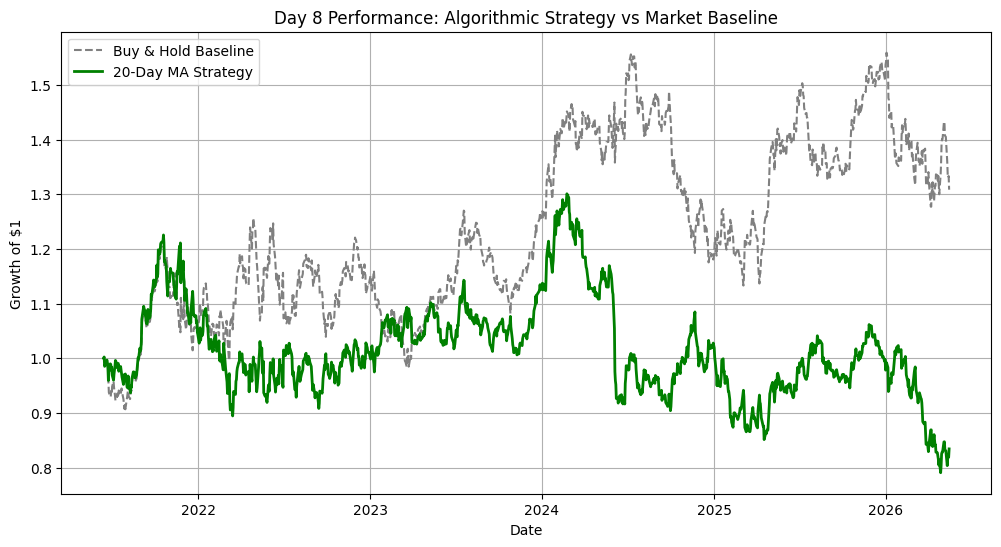

In [11]:
#MA Strategy
plt.figure(figsize=(12, 6))

plt.plot(df['Baseline_Equity'], label='Buy & Hold Baseline', color='gray', linestyle='--')
plt.plot(df['Strategy_Equity'], label='20-Day MA Strategy', color='green', linewidth=2)

plt.title('Day 8 Performance: Algorithmic Strategy vs Market Baseline')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# This will show if our strategy is actually generating trades
print(df['Position'].value_counts())

Position
 1.0    651
-1.0    567
Name: count, dtype: int64


In [13]:
# Create a list to store our results
performance_results = []

for w in range(5, 101, 5):
    temp_df = data.copy().sort_index()
    
    temp_df['MA'] = temp_df['Close'].rolling(window=w).mean()
    temp_df['Signal'] = np.where(temp_df['Close'] > temp_df['MA'], 1, -1)
    temp_df['Position'] = temp_df['Signal'].shift(1)
    temp_df = temp_df.dropna()
    
    # Calculate returns
    temp_df['Market_Return'] = temp_df['Close'].pct_change()
    temp_df['Strategy_Return'] = temp_df['Market_Return'] * temp_df['Position']
    
    # Calculate total cumulative return 
    total_return = (1 + temp_df['Strategy_Return'].fillna(0)).prod() - 1
    performance_results.append({'Window_Size': w, 'Total_Return': total_return})

results_df = pd.DataFrame(performance_results)
best_windows = results_df.sort_values(by='Total_Return', ascending=False)

print("--- TOP 5 MOST PROFITABLE WINDOWS ---")
print(best_windows.head())
print("\n--- TOP 5 WORST PERFORMING WINDOWS ---")
print(best_windows.tail())

--- TOP 5 MOST PROFITABLE WINDOWS ---
    Window_Size  Total_Return
6            35      0.192782
5            30      0.124336
9            50      0.056113
1            10      0.008517
10           55     -0.048853

--- TOP 5 WORST PERFORMING WINDOWS ---
    Window_Size  Total_Return
15           80     -0.565643
18           95     -0.604009
19          100     -0.604570
17           90     -0.635429
16           85     -0.646886


In [14]:
#windows 20 is the fast moving average and 50 is the slow moving acerage
df_dual = data.copy().sort_index()

df_dual['Fast_MA'] = df_dual['Close'].rolling(window = 20).mean()
df_dual['Slow_MA'] = df_dual['Close'].rolling(window = 50).mean()

df_dual['Signal'] = np.where(df_dual['Fast_MA'] > df_dual['Slow_MA'],1 ,-1)
df_dual['Position'] = df_dual['Signal'].shift(1)

df_dual = df_dual.dropna()

In [15]:
df_dual['Market_Return'] = df_dual['Close'].pct_change()
df_dual['Strategy_Return'] = df_dual['Market_Return'] * df_dual['Position']

df_dual['Baseline_Equity'] = (1 + df_dual['Market_Return'].fillna(0)).cumprod()
df_dual['Strategy_Equity'] = (1 + df_dual['Strategy_Return'].fillna(0)).cumprod()

df_dual.tail()

Price,Close,High,Low,Open,Volume,SMA_10,Rolling_Vol_10,Fast_MA,Slow_MA,Signal,Position,Market_Return,Strategy_Return,Baseline_Equity,Strategy_Equity
Date,,,,,,,,,,,,,,,
2026-05-11,1381.811035,1421.427912,1375.639618,1413.464731,15261787,1382.771643,46.683995,1382.771643,1377.353687,1,1.0,-0.032748,-0.032748,1.484627,0.799528
2026-05-12,1357.722412,1387.086643,1354.039489,1385.593547,24357500,1385.205389,43.819164,1385.205389,1376.063650,1,1.0,-0.017433,-0.017433,1.458746,0.785590
2026-05-13,1352.546387,1366.083771,1346.175817,1355.134396,13797989,1385.937006,43.104340,1385.937006,1375.273303,1,1.0,-0.003812,-0.003812,1.453185,0.782595
2026-05-14,1355.532593,1371.657986,1352.148216,1358.916848,17303059,1386.857745,42.193699,1386.857745,1374.377444,1,1.0,0.002208,0.002208,1.456393,0.784323
2026-05-15,1330.249512,1358.518831,1323.082575,1350.555649,19976192,1385.434326,43.648099,1385.434326,1373.232737,1,1.0,-0.018652,-0.018652,1.429229,0.769694


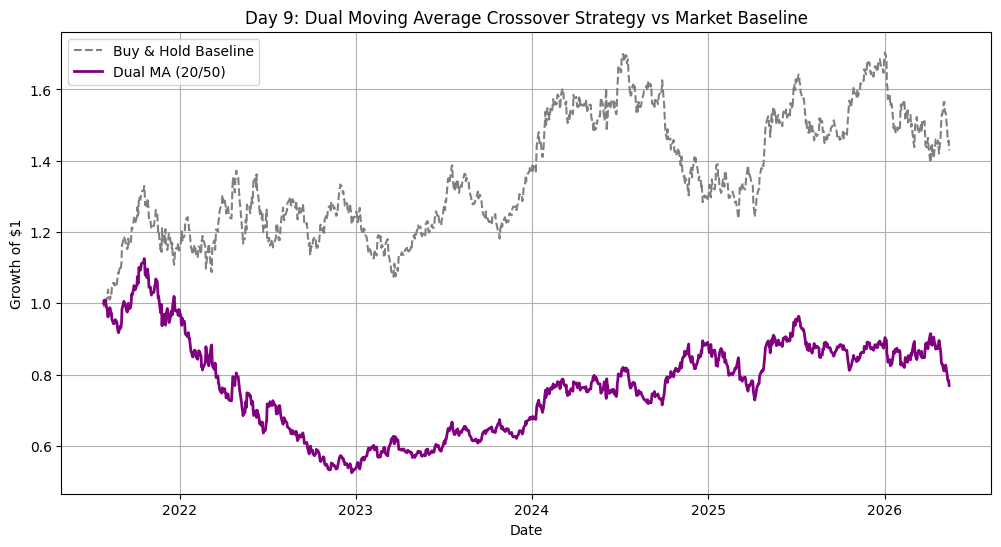

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(df_dual['Baseline_Equity'], label='Buy & Hold Baseline', color='gray', linestyle='--')
plt.plot(df_dual['Strategy_Equity'], label=f'Dual MA ({20}/{50})', color='purple', linewidth=2)

plt.title(f'Day 9: Dual Moving Average Crossover Strategy vs Market Baseline')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
 print(f"Start Date: {df_dual.index.min().date()} | End Date: {df_dual.index.max().date()} | Total Trading Days: {len(df_dual)}")

Start Date: 2021-07-27 | End Date: 2026-05-15 | Total Trading Days: 1188


In [18]:
# Time for ADX
df_diag = data.copy()
df_diag['SMA_100'] = df_diag['Close'].rolling(window=100).mean()
df_diag['Dev'] = (df_diag['Close'] - df_diag['SMA_100']).abs() / df_diag['SMA_100']

print(f"Average Deviation from Long-Term Mean: {df_diag['Dev'].mean() * 100:.2f}%")

Average Deviation from Long-Term Mean: 5.61%


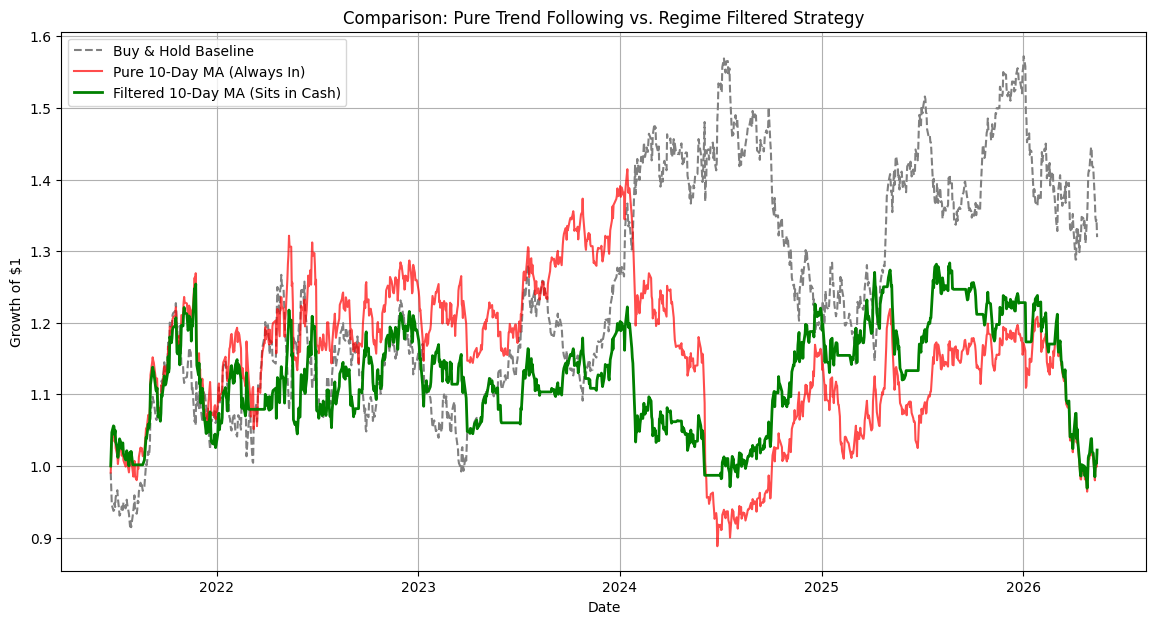

Final Baseline Return: 31.96%
Final Pure 10-Day MA Return: 1.72%
Final Filtered Strategy Return: 2.22%


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#Baseline
df_comp = data.copy().sort_index()
df_comp['Market_Return'] = df_comp['Close'].pct_change()

#1: Pure 10-Day Moving Average (Always In the Market) ---
df_comp['MA_10'] = df_comp['Close'].rolling(window=10).mean()
df_comp['Strat1_Signal'] = np.where(df_comp['Close'] > df_comp['MA_10'], 1, -1)
df_comp['Strat1_Pos'] = df_comp['Strat1_Signal'].shift(1)
df_comp['Strat1_Return'] = df_comp['Market_Return'] * df_comp['Strat1_Pos']

# 2: 10-Day MA WITH ADX Regime Filter (Sits in Cash) ---
# Calculate True Range and Directional Movement
df_comp['H-L'] = df_comp['High'] - df_comp['Low']
df_comp['H-PC'] = (df_comp['High'] - df_comp['Close'].shift(1)).abs()
df_comp['L-PC'] = (df_comp['Low'] - df_comp['Close'].shift(1)).abs()
df_comp['TR'] = df_comp[['H-L', 'H-PC', 'L-PC']].max(axis=1)

df_comp['UpMove'] = df_comp['High'] - df_comp['High'].shift(1)
df_comp['DownMove'] = df_comp['Low'].shift(1) - df_comp['Low']
df_comp['+DM'] = np.where((df_comp['UpMove'] > df_comp['DownMove']) & (df_comp['UpMove'] > 0), df_comp['UpMove'], 0)
df_comp['-DM'] = np.where((df_comp['DownMove'] > df_comp['UpMove']) & (df_comp['DownMove'] > 0), df_comp['DownMove'], 0)

# Smooth over 14 days to compute ADX
adx_w = 14
df_comp['TR_s'] = df_comp['TR'].rolling(window=adx_w).sum()
df_comp['+DM_s'] = df_comp['+DM'].rolling(window=adx_w).sum()
df_comp['-DM_s'] = df_comp['-DM'].rolling(window=adx_w).sum()

df_comp['+DI'] = 100 * (df_comp['+DM_s'] / df_comp['TR_s'])
df_comp['-DI'] = 100 * (df_comp['-DM_s'] / df_comp['TR_s'])
df_comp['DX'] = 100 * (df_comp['+DI'] - df_comp['-DI']).abs() / (df_comp['+DI'] + df_comp['-DI'])
df_comp['ADX'] = df_comp['DX'].rolling(window=adx_w).mean()

# Apply the filter: If ADX <= 22, force position to 0 (Cash)
df_comp['Strat2_Signal'] = np.where(df_comp['ADX'] > 22, df_comp['Strat1_Signal'], 0)
df_comp['Strat2_Pos'] = df_comp['Strat2_Signal'].shift(1)
df_comp['Strat2_Return'] = df_comp['Market_Return'] * df_comp['Strat2_Pos']

# --- 2. Calculate Cumulative Equity Performance ---
df_comp = df_comp.dropna()
df_comp['Baseline_Cum'] = (1 + df_comp['Market_Return'].fillna(0)).cumprod()
df_comp['Unfiltered_Cum'] = (1 + df_comp['Strat1_Return'].fillna(0)).cumprod()
df_comp['Filtered_Cum'] = (1 + df_comp['Strat2_Return'].fillna(0)).cumprod()

#  Plot Comparison Side by Side
plt.figure(figsize=(14, 7))
plt.plot(df_comp['Baseline_Cum'], label='Buy & Hold Baseline', color='gray', linestyle='--')
plt.plot(df_comp['Unfiltered_Cum'], label='Pure 10-Day MA (Always In)', color='red', alpha=0.7)
plt.plot(df_comp['Filtered_Cum'], label='Filtered 10-Day MA (Sits in Cash)', color='green', linewidth=2)

plt.title('Comparison: Pure Trend Following vs. Regime Filtered Strategy')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final Baseline Return: {(df_comp['Baseline_Cum'].iloc[-1] - 1) * 100:.2f}%")
print(f"Final Pure 10-Day MA Return: {(df_comp['Unfiltered_Cum'].iloc[-1] - 1) * 100:.2f}%")
print(f"Final Filtered Strategy Return: {(df_comp['Filtered_Cum'].iloc[-1] - 1) * 100:.2f}%")

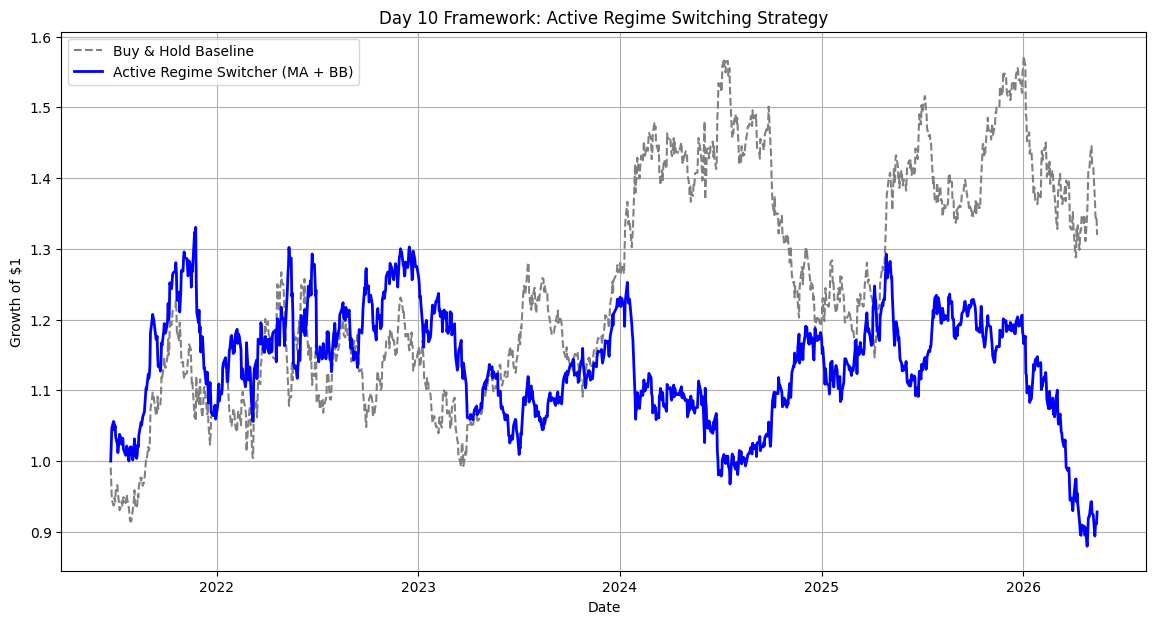

Final Baseline Return: 31.96%
Final Active Switcher Return: -7.19%


In [20]:
#Create a clean copy of your data named df_custom.Compute a 10-day moving average of the 'Close' price and name the column MA_10.
#Create the trend signal column named Trend_Signal: If 'Close' > MA_10, the signal is 1, otherwise -1. Use np.where().
#Compute a 20-day moving average (MA_20) and a 20-day rolling standard deviation (STD_20) of the 'Close' price using 
#.rolling(window=20).mean() and .std().Create the Bollinger upper and lower bands:
#Upper_B = $MA_{20} + (2 \times STD_{20})$Lower_B = $MA_{20} - (2 \times STD_{20})$

df_active = data.copy().sort_index()
df_active['Market_Return'] = df['Close'].pct_change()

df_active['MA_10'] = df_active['Close'].rolling(window=10).mean()
df_active['Trend_Signal'] = np.where(df_active['Close'] >df_active['MA_10'], 1, -1)

df_active['MA_20'] = df_active['Close'].rolling(window=20).mean()
df_active['STD_20'] = df_active['Close'].rolling(window=20).std()
df_active['Upper_B'] = df_active['MA_20'] + (df_active['STD_20']*2 )
df_active['Lower_B'] = df_active['MA_20'] - (df_active['STD_20']*2 )

df_active['MR_Signal'] = 0
df_active.loc[df_active['Close'] < df_active['Lower_B'], 'MR_Signal'] = 1   # Buy bottom
df_active.loc[df_active['Close'] > df_active['Upper_B'], 'MR_Signal'] = -1  # Sell top
df_active['MR_Signal'] = df_active['MR_Signal'].replace(0, np.nan).ffill().fillna(0)

# 14-Day ADX
df_active['H-L'] = df_active['High'] - df_active['Low']
df_active['H-PC'] = (df_active['High'] - df_active['Close'].shift(1)).abs()
df_active['L-PC'] = (df_active['Low'] - df_active['Close'].shift(1)).abs()
df_active['TR'] = df_active[['H-L', 'H-PC', 'L-PC']].max(axis=1)

df_active['UpMove'] = df_active['High'] - df_active['High'].shift(1)
df_active['DownMove'] = df_active['Low'].shift(1) - df_active['Low']
df_active['+DM'] = np.where((df_active['UpMove'] > df_active['DownMove']) & (df_active['UpMove'] > 0), df_active['UpMove'], 0)
df_active['-DM'] = np.where((df_active['DownMove'] > df_active['UpMove']) & (df_active['DownMove'] > 0), df_active['DownMove'], 0)

adx_w = 14
df_active['TR_s'] = df_active['TR'].rolling(window=adx_w).sum()
df_active['+DM_s'] = df_active['+DM'].rolling(window=adx_w).sum()
df_active['-DM_s'] = df_active['-DM'].rolling(window=adx_w).sum()

df_active['+DI'] = 100 * (df_active['+DM_s'] / df_active['TR_s'])
df_active['-DI'] = 100 * (df_active['-DM_s'] / df_active['TR_s'])
df_active['DX'] = 100 * (df_active['+DI'] - df_active['-DI']).abs() / (df_active['+DI'] + df_active['-DI'])
df_active['ADX'] = df_active['DX'].rolling(window=adx_w).mean()

# If ADX > 22 -> Use Trend Signal. If ADX <= 22 -> Use Mean Reversion Signal
df_active['Master_Signal'] = np.where(df_active['ADX'] > 22, df_active['Trend_Signal'], df_active['MR_Signal'])
df_active['Master_Pos'] = df_active['Master_Signal'].shift(1)
df_active['Active_Strat_Return'] = df_active['Market_Return'] * df_active['Master_Pos']

# Cumulative Performance
df_active = df_active.dropna()
df_active['Baseline_Cum'] = (1 + df_active['Market_Return'].fillna(0)).cumprod()
df_active['Active_Switcher_Cum'] = (1 + df_active['Active_Strat_Return'].fillna(0)).cumprod()

plt.figure(figsize=(14, 7))
plt.plot(df_active['Baseline_Cum'], label='Buy & Hold Baseline', color='gray', linestyle='--')
plt.plot(df_active['Active_Switcher_Cum'], label='Active Regime Switcher (MA + BB)', color='blue', linewidth=2)

plt.title('Day 10 Framework: Active Regime Switching Strategy')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final Baseline Return: {(df_active['Baseline_Cum'].iloc[-1] - 1) * 100:.2f}%")
print(f"Final Active Switcher Return: {(df_active['Active_Switcher_Cum'].iloc[-1] - 1) * 100:.2f}%")

In [21]:
#analyzing how the return generation is not so successful until now
df_metrics = df_active[['Market_Return', 'Active_Strat_Return']].copy()

print("Daily Stats: Baseline")
print(df_metrics['Market_Return'].describe())
print("Daily Stats: Active Return")
print(df_metrics['Active_Strat_Return'].describe())

Daily Stats: Baseline
count    1211.000000
mean        0.000329
std         0.014123
min        -0.074851
25%        -0.008008
50%         0.000361
75%         0.007848
max         0.070192
Name: Market_Return, dtype: float64
Daily Stats: Active Return
count    1211.000000
mean        0.000038
std         0.014125
min        -0.072025
25%        -0.007995
50%         0.000296
75%         0.007916
max         0.074851
Name: Active_Strat_Return, dtype: float64


In [22]:
#using some absolute methods to calculate our return, Sharpe Ratio here
sharpe_baseline = (df_metrics['Market_Return'].mean()/df_metrics['Market_Return'].std())*np.sqrt(252)
sharpe_active = (df_metrics['Active_Strat_Return'].mean()/df_metrics['Active_Strat_Return'].std())*np.sqrt(252)

print(f"Annualized Sharpe Baseline: {sharpe_baseline :.2f}")
print(f"Annualized Sharpe Active: {sharpe_active :.2f}")

Annualized Sharpe Baseline: 0.37
Annualized Sharpe Active: 0.04


In [23]:
#Sortino ratio here, it does not penalises the sudden upward omvements, basically ignores the sudden upward movements in standard deviation
downside_baseline = df_metrics['Market_Return'].copy()
downside_baseline[downside_baseline > 0] = 0

downside_active = df_metrics['Active_Strat_Return'].copy()
downside_active[downside_active > 0] = 0

std_down_baseline = np.sqrt(np.mean(downside_baseline**2))
std_down_active = np.sqrt(np.mean(downside_active**2))

sortino_baseline = (df_metrics['Market_Return'].mean()/std_down_baseline)*np.sqrt(252)
sortino_active = (df_metrics['Active_Strat_Return'].mean()/std_down_active)*np.sqrt(252)
print(f"Annualized Sortino Ratio (Baseline): {sortino_baseline:.2f}")
print(f"Annualized Sortino Ratio (Active Switcher): {sortino_active:.2f}")

Annualized Sortino Ratio (Baseline): 0.54
Annualized Sortino Ratio (Active Switcher): 0.06


In [24]:
#Calculate the running peaks for both strategies
df_metrics['Baseline_Peak'] = df_active['Baseline_Cum'].cummax()
df_metrics['Active_Peak'] = df_active['Active_Switcher_Cum'].cummax()

df_metrics['Baseline_DD'] = (df_active['Baseline_Cum'] - df_metrics['Baseline_Peak']) / df_metrics['Baseline_Peak']
df_metrics['Active_DD'] = (df_active['Active_Switcher_Cum'] - df_metrics['Active_Peak']) / df_metrics['Active_Peak']

# 3. Find the worst-case drop (Minimum value)
max_dd_baseline = df_metrics['Baseline_DD'].min()
max_dd_active = df_metrics['Active_DD'].min()

print(f"Maximum Drawdown (Baseline): {max_dd_baseline * 100:.2f}%")
print(f"Maximum Drawdown (Active Switcher): {max_dd_active * 100:.2f}%")

Maximum Drawdown (Baseline): -27.18%
Maximum Drawdown (Active Switcher): -33.88%


In [25]:
win_rate_baseline = (df_metrics['Market_Return']>0).mean()
win_rate_active = (df_metrics['Active_Strat_Return']>0).mean()

gross_profit_baseline = df_metrics[df_metrics['Market_Return'] > 0]['Market_Return'].sum()
gross_loss_baseline = df_metrics[df_metrics['Market_Return'] < 0]['Market_Return'].sum()
profit_factor_baseline = gross_profit_baseline / abs(gross_loss_baseline)

gross_profit_active = df_metrics[df_metrics['Active_Strat_Return'] > 0]['Active_Strat_Return'].sum()
gross_loss_active = df_metrics[df_metrics['Active_Strat_Return'] < 0]['Active_Strat_Return'].sum()
profit_factor_active = gross_profit_active / abs(gross_loss_active)

print(f"Win_Rate (Baseline): {win_rate_baseline * 100:.2f}%")
print(f"Profit_Factor (Baseline): {profit_factor_baseline:.2f}\n")
print(f"Win_Rate (Active Switcher): {win_rate_active * 100:.2f}%")
print(f"Profit_Factor (Active Switcher): {profit_factor_active:.2f}")

Win_Rate (Baseline): 51.20%
Profit_Factor (Baseline): 1.07

Win_Rate (Active Switcher): 50.95%
Profit_Factor (Active Switcher): 1.01


--- NEW FAST-SWITCHER METRICS ---
New Annualized Sharpe: 0.01
New Annualized Sortino: 0.01
New Maximum Drawdown: -41.47%



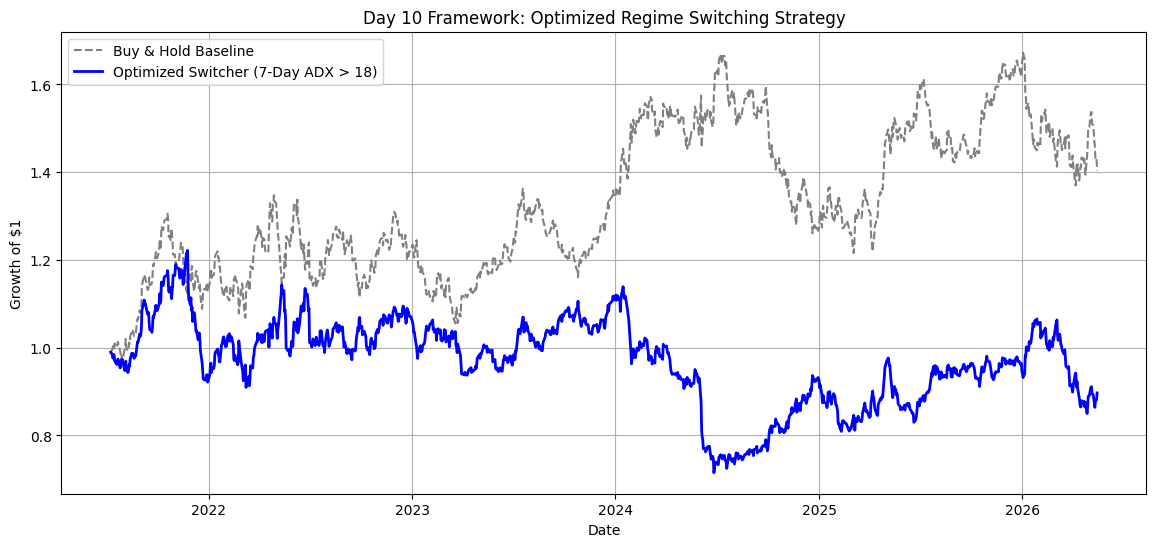

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Make a fresh copy to avoid changing previous cells
df_sweep = df_active.copy()

# --- COMPONENT C: NEW OPTIMIZED REGIME FILTER (7-Day Faster ADX) ---
adx_w = 7  # Faster lookback window

df_sweep['TR_s'] = df_sweep['TR'].rolling(window=adx_w).sum()
df_sweep['+DM_s'] = df_sweep['+DM'].rolling(window=adx_w).sum()
df_sweep['-DM_s'] = df_sweep['-DM'].rolling(window=adx_w).sum()

df_sweep['+DI'] = 100 * (df_sweep['+DM_s'] / df_sweep['TR_s'])
df_sweep['-DI'] = 100 * (df_sweep['-DM_s'] / df_sweep['TR_s'])
df_sweep['DX'] = 100 * (df_sweep['+DI'] - df_sweep['-DI']).abs() / (df_sweep['+DI'] + df_sweep['-DI'])
df_sweep['ADX'] = df_sweep['DX'].rolling(window=adx_w).mean()

# --- OPTIMIZED SWITCHER LOGIC ---
# Using 18 instead of 22 to force the system into trend-following mode much sooner
df_sweep['Master_Signal'] = np.where(df_sweep['ADX'] > 18, df_sweep['Trend_Signal'], df_sweep['MR_Signal'])

# Re-calculate execution position and compounding returns
df_sweep['Master_Pos'] = df_sweep['Master_Signal'].shift(1)
df_sweep['Active_Strat_Return'] = df_sweep['Market_Return'] * df_sweep['Master_Pos']
df_sweep = df_sweep.dropna()

df_sweep['Baseline_Cum'] = (1 + df_sweep['Market_Return'].fillna(0)).cumprod()
df_sweep['Active_Switcher_Cum'] = (1 + df_sweep['Active_Strat_Return'].fillna(0)).cumprod()

# --- PRINT NEW PERFORMANCE DASHBOARD ---
sharpe_active = (df_sweep['Active_Strat_Return'].mean() / df_sweep['Active_Strat_Return'].std()) * np.sqrt(252)

downside_active = df_sweep['Active_Strat_Return'].copy()
downside_active[downside_active > 0] = 0
std_down_active = np.sqrt(np.mean(downside_active**2))
sortino_active = (df_sweep['Active_Strat_Return'].mean() / std_down_active) * np.sqrt(252)

df_sweep['Active_Peak'] = df_sweep['Active_Switcher_Cum'].cummax()
df_sweep['Active_DD'] = (df_sweep['Active_Switcher_Cum'] - df_sweep['Active_Peak']) / df_sweep['Active_Peak']
max_dd_active = df_sweep['Active_DD'].min()

print("--- NEW FAST-SWITCHER METRICS ---")
print(f"New Annualized Sharpe: {sharpe_active:.2f}")
print(f"New Annualized Sortino: {sortino_active:.2f}")
print(f"New Maximum Drawdown: {max_dd_active * 100:.2f}%\n")

# --- PLOT THE NEW RESULTS ---
plt.figure(figsize=(14, 6))
plt.plot(df_sweep['Baseline_Cum'], label='Buy & Hold Baseline', color='gray', linestyle='--')
plt.plot(df_sweep['Active_Switcher_Cum'], label='Optimized Switcher (7-Day ADX > 18)', color='blue', linewidth=2)
plt.title('Day 10 Framework: Optimized Regime Switching Strategy')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.grid(True)
plt.legend()
plt.show()

In [27]:
#accessing multi asset data
tickers = ['SPY', 'QQQ', 'GLD', 'TLT']
portfolio_data = {}

print("--- DOWNLOADING MULTI-ASSET DATA ---")
for ticker in tickers:
    df = yf.download(ticker, start="2021-01-01", end="2026-05-25",auto_adjust=True)
    
    # Check if we have multi-index columns and flatten them if needed
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    
    # Dynamic column identification fallback
    if 'Adj Close' in df.columns:
        close_col = 'Adj Close'
    elif 'Close' in df.columns:
        close_col = 'Close'
    else:
        raise KeyError(f"Could not find a price column in {df.columns}")
        
    # Calculate daily returns safely using the identified column
    df['Daily_Return'] = df[close_col].pct_change()
    
    # Store the clean DataFrame inside our dictionary
    portfolio_data[ticker] = df
    print(f"Successfully loaded {ticker} using column '{close_col}' | Rows: {len(df)}")

print("\nAll assets packed safely into the portfolio dictionary!")

--- DOWNLOADING MULTI-ASSET DATA ---


[*********************100%***********************]  1 of 1 completed


Successfully loaded SPY using column 'Close' | Rows: 1353


[*********************100%***********************]  1 of 1 completed


Successfully loaded QQQ using column 'Close' | Rows: 1353


[*********************100%***********************]  1 of 1 completed


Successfully loaded GLD using column 'Close' | Rows: 1353


[*********************100%***********************]  1 of 1 completed

Successfully loaded TLT using column 'Close' | Rows: 1353

All assets packed safely into the portfolio dictionary!


In [28]:
# Create a brand new DataFrame to hold just the daily returns
df_returns = pd.DataFrame()

# Pull the daily return column for each asset and line them up side-by-side
for ticker in tickers:
    df_returns[ticker] = portfolio_data[ticker]['Daily_Return']

# Drop the very first row because pct_change() always creates a NaN on day 1
df_returns = df_returns.dropna()

print("\n--- MASTER RETURNS SCOREBOARD ---")
print(df_returns.head())


--- MASTER RETURNS SCOREBOARD ---
                 SPY       QQQ       GLD       TLT
Date                                              
2021-01-05  0.006887  0.008244  0.002962 -0.007426
2021-01-06  0.005978 -0.013852 -0.016241 -0.020528
2021-01-07  0.014857  0.024192 -0.002335 -0.008815
2021-01-08  0.005698  0.012858 -0.034210 -0.003228
2021-01-11 -0.006741 -0.014450 -0.001961 -0.001652


In [29]:
#finding correlation among the given 4 stocks
correlation_matrix = df_returns.corr()
print(f"Correlation matrix\n {correlation_matrix.round(2)}")

Correlation matrix
       SPY   QQQ   GLD   TLT
SPY  1.00  0.95  0.14  0.07
QQQ  0.95  1.00  0.13  0.09
GLD  0.14  0.13  1.00  0.22
TLT  0.07  0.09  0.22  1.00


In [30]:
#2 methods of allocating how much money to be given to each stock
asset_vols = df_returns.std()

num_assets = len(tickers)
equal_weights = np.ones(num_assets)/num_assets

invers_vols = 1/asset_vols
risk_parity_weights = invers_vols/invers_vols.sum()

print(f"Engine 1 equal wight case:")
for t,w in zip(tickers, equal_weights):
    print(f"{t}: {w*100:.2f}%")

print("Engine 2 calculated with inverse of std i.e. minimising risk")
for t,w in zip(tickers, risk_parity_weights):
    print(f"{t}: {w*100:.2f}%")

Engine 1 equal wight case:
SPY: 25.00%
QQQ: 25.00%
GLD: 25.00%
TLT: 25.00%
Engine 2 calculated with inverse of std i.e. minimising risk
SPY: 26.46%
QQQ: 19.96%
GLD: 25.12%
TLT: 28.46%


Final value of the equal weight case: 1.74
Final value of the risk parity weight case: 1.66


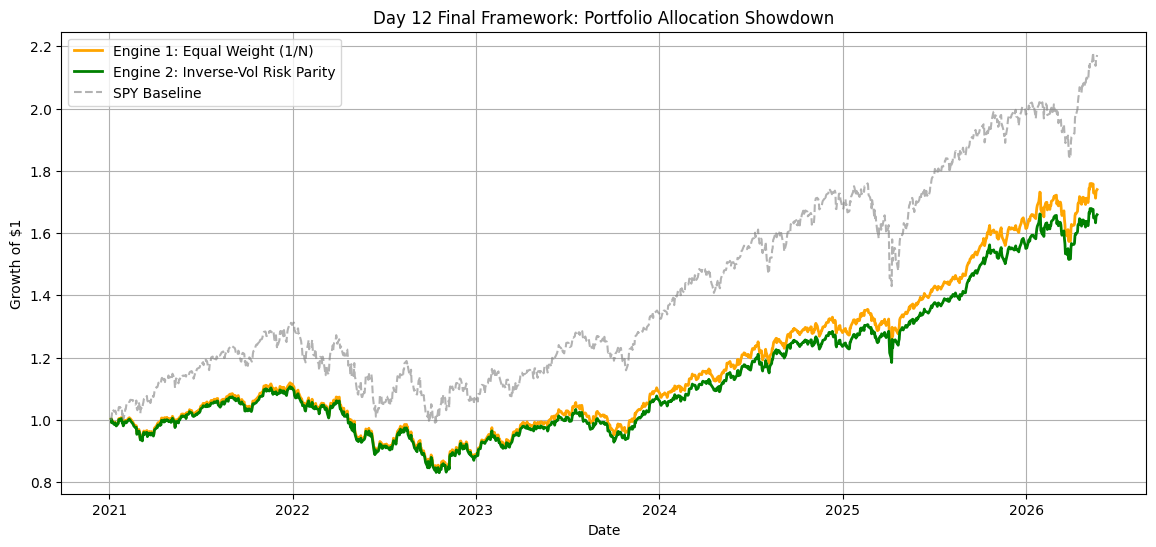

In [31]:
w_equal = np.array([0.25, 0.25, 0.25, 0.25])
w_risk_parity = np.array([0.2646, 0.1996, 0.2512, 0.2846])
df_returns['Equal_Portfolio_Return'] = df_returns[['SPY', 'QQQ', 'GLD', 'TLT']].dot(w_equal)
df_returns['RP_Portfolio_Return'] = df_returns[['SPY', 'QQQ', 'GLD', 'TLT']].dot(w_risk_parity)
df_returns['Equal_Cum'] = (1 + df_returns['Equal_Portfolio_Return']).cumprod()
df_returns['RP_Cum'] = (1 + df_returns['RP_Portfolio_Return']).cumprod()

print(f"Final value of the equal weight case: {df_returns['Equal_Cum'].iloc[-1]:.2f}")
print(f"Final value of the risk parity weight case: {df_returns['RP_Cum'].iloc[-1]:.2f}")

spy_df = portfolio_data['SPY']

plt.figure(figsize=(14, 6))
plt.plot(df_returns['Equal_Cum'], label='Engine 1: Equal Weight (1/N)', color='orange', linewidth=2)
plt.plot(df_returns['RP_Cum'], label='Engine 2: Inverse-Vol Risk Parity', color='green', linewidth=2)
plt.plot(spy_df['Close'] / spy_df['Close'].iloc[0], 
         label='SPY Baseline', color='gray', linestyle='--', alpha=0.6)
plt.title('Day 12 Final Framework: Portfolio Allocation Showdown')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.grid(True)
plt.legend()
plt.show()

In [32]:
# day-15
#calculating the annual return of the two methods,mentioned above
total_days = len(daily_returns)
years = total_days/252

print(f"Dataset covers {total_days} trading days (approx. {years:.2f} years).\n")

final_equal_value = df_returns['Equal_Cum'].iloc[-1]
final_rp_value = df_returns['RP_Cum'].iloc[-1]

ann_return_equal = (final_equal_value)**(1/years)-1
ann_return_rp = (final_rp_value)**(1/years)-1

print("--- PART 1: ANNUALIZED RETURN RESULTS ---")
print(f"Equal Weight Portfolio Annualized Return: {ann_return_equal * 100:.2f}% per year")
print(f"Risk Parity Portfolio Annualized Return:  {ann_return_rp * 100:.2f}% per year")

Dataset covers 1237 trading days (approx. 4.91 years).

--- PART 1: ANNUALIZED RETURN RESULTS ---
Equal Weight Portfolio Annualized Return: 11.94% per year
Risk Parity Portfolio Annualized Return:  10.86% per year


In [33]:
#calculating their volatility for Sharpe
daily_vol_equal = df_returns['Equal_Portfolio_Return'].std()
daily_vol_rp = df_returns['RP_Portfolio_Return'].std()

ann_vol_equal = daily_vol_equal*np.sqrt(252)
ann_vol_rp = daily_vol_rp*np.sqrt(252)

print("--- PART 2: ANNUALIZED VOLATILITY RESULTS ---")
print(f"Equal Weight Portfolio Annualized Volatility: {ann_vol_equal * 100:.2f}%")
print(f"Risk Parity Portfolio Annualized Volatility:  {ann_vol_rp * 100:.2f}%")

--- PART 2: ANNUALIZED VOLATILITY RESULTS ---
Equal Weight Portfolio Annualized Volatility: 12.42%
Risk Parity Portfolio Annualized Volatility:  11.97%


In [34]:
#Sharpe Ratio
sharpe_equal = ann_return_equal/ann_vol_equal
sharpe_rp = ann_return_rp/ann_vol_rp

print("--- PART 3: SHARPE RATIO RESULTS ---")
print(f"Equal Weight Portfolio Sharpe Ratio: {sharpe_equal:.2f}")
print(f"Risk Parity Portfolio Sharpe Ratio:  {sharpe_rp:.2f}")

--- PART 3: SHARPE RATIO RESULTS ---
Equal Weight Portfolio Sharpe Ratio: 0.96
Risk Parity Portfolio Sharpe Ratio:  0.91


In [35]:
# Maximum dropdown
peak_equal = df_returns['Equal_Cum'].cummax()
peak_rp = df_returns['RP_Cum'].cummax()

drawdowns_equal = (df_returns['Equal_Cum'] - peak_equal)/peak_equal
drawdowns_rp = (df_returns['RP_Cum'] - peak_rp)/peak_rp

max_dd_equal = drawdowns_equal.min()
max_dd_rp = drawdowns_rp.min()

print("--- PART 4: MAXIMUM DRAWDOWN RESULTS ---")
print(f"Equal Weight Portfolio Max Drawdown: {max_dd_equal * 100:.2f}%")
print(f"Risk Parity Portfolio Max Drawdown:  {max_dd_rp * 100:.2f}%")

--- PART 4: MAXIMUM DRAWDOWN RESULTS ---
Equal Weight Portfolio Max Drawdown: -25.15%
Risk Parity Portfolio Max Drawdown:  -24.97%


In [36]:
# plugging in the final outputs for the day15
dashboard_data = {'Equal Weight (1/N)': [ann_return_equal * 100, ann_vol_equal * 100, sharpe_equal, max_dd_equal * 100],
        'Risk Parity (Inv-Vol)': [ann_return_rp * 100, ann_vol_rp * 100, sharpe_rp, max_dd_rp * 100]}

metrics_df = pd.DataFrame.from_dict(
    dashboard_data, 
    orient='index', 
    columns=['Ann. Return (%)', 'Ann. Volatility (%)', 'Sharpe Ratio', 'Max Drawdown (%)']
)
print("Executive Performance Dashboard")
display(metrics_df.round(2))

Executive Performance Dashboard


,Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Max Drawdown (%)
Equal Weight (1/N),11.94,12.42,0.96,-25.15
Risk Parity (Inv-Vol),10.86,11.97,0.91,-24.97


In [37]:
# Calculating SPY baseline for comparing do we have written those codes for just underperforming or we have done smthng
spy_raw_returns = portfolio_data['SPY']['Close'].pct_change().dropna()

common_index = df_returns.index.intersection(spy_raw_returns.index)
spy_raw_returns = spy_raw_returns.loc[common_index]

spy_cum = (1 + spy_raw_returns).cumprod()

total_days_spy = len(spy_raw_returns)
years_spy = total_days_spy / 252

ann_return_spy = (spy_cum.iloc[-1])**(1/years_spy) - 1
ann_vol_spy = spy_raw_returns.std()*np.sqrt(252)
sharpe_spy = ann_return_spy /ann_vol_spy

peak_spy = spy_cum.cummax()
drawdowns_spy = (spy_cum-peak_spy)/peak_spy
max_dd_spy = drawdowns_spy.min()

metrics_df.loc['SPY Baseline'] = [ann_return_spy * 100, ann_vol_spy * 100, sharpe_spy, max_dd_spy * 100]

print("DAY 15 COMPLETE: FINAL PORTFOLIO VS BASELINE AUDIT")
display(metrics_df.round(2))

DAY 15 COMPLETE: FINAL PORTFOLIO VS BASELINE AUDIT


,Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Max Drawdown (%)
Equal Weight (1/N),11.94,12.42,0.96,-25.15
Risk Parity (Inv-Vol),10.86,11.97,0.91,-24.97
SPY Baseline,15.55,16.88,0.92,-24.50


In [38]:
#day16
df_raw = yf.download(tickers, start="2018-01-01", end="2024-01-01")['Close']

df_asset_returns = df_raw.pct_change().dropna()

num_assets = len(df_asset_returns.columns)
target_allocation = np.array([1.0 / num_assets] * num_assets)
current_weights = target_allocation.copy()

weights_matrix = pd.DataFrame(index=df_asset_returns.index, columns=df_asset_returns.columns, dtype=float)
transaction_costs = pd.Series(0.0, index=df_asset_returns.index)
fee_rate = 0.0010

for i in range(len(df_asset_returns)):
    date = df_asset_returns.index[i]
    daily_rets = df_asset_returns.iloc[i].values
    
    weights_matrix.loc[date] = pd.Series(current_weights, index=df_asset_returns.columns)
    raw_drift = current_weights * (1 + daily_rets)
    sum_drift = np.sum(raw_drift)
    
    if sum_drift == 0 or np.isnan(sum_drift):
        current_weights = target_allocation.copy()
    else:
        current_weights = raw_drift / sum_drift
        
    if i < len(df_asset_returns) - 1:
        next_date = df_asset_returns.index[i + 1]
        if date.month != next_date.month:
            turnover = np.sum(np.abs(current_weights - target_allocation))
            transaction_costs.loc[date] = turnover * fee_rate
            current_weights = target_allocation.copy()

raw_portfolio_returns = (df_asset_returns * weights_matrix).sum(axis=1)
net_portfolio_returns = raw_portfolio_returns - transaction_costs
portfolio_cum_net = (1 + net_portfolio_returns).cumprod()

print(f"Total Trading Days Processed: {len(df_asset_returns)}")
print(f"Final Net Portfolio Wealth Curve Value: {portfolio_cum_net.iloc[-1]:.4f}")

[*********************100%***********************]  4 of 4 completed


Total Trading Days Processed: 1508
Final Net Portfolio Wealth Curve Value: 1.7091


In [39]:
print(df_returns.max())

SPY                       0.105019
QQQ                       0.120031
GLD                       0.063587
TLT                       0.038474
Equal_Portfolio_Return    0.066982
RP_Portfolio_Return       0.062714
Equal_Cum                 1.759330
RP_Cum                    1.678751
dtype: float64


In [40]:
benchmark_cum = (1 + df_asset_returns['SPY']).cumprod()

final_strategy = portfolio_cum_net.iloc[-1]
final_benchmark = benchmark_cum.iloc[-1]

print(f"Strategy Final Value (Rebalanced Multi-Asset): ${final_strategy:.4f}")
print(f"Benchmark Final Value (Buy-and-Hold SPY):      ${final_benchmark:.4f}")

difference = (final_strategy - final_benchmark) * 100
if final_strategy > final_benchmark:
    print(f"Better performance by{difference:.2f} cents on the dollar.")
else:
    print(f"Underperformance by {abs(difference):.2f} cents on the dollar.")

Strategy Final Value (Rebalanced Multi-Asset): $1.7091
Benchmark Final Value (Buy-and-Hold SPY):      $1.9554
Underperformance by 24.63 cents on the dollar.


In [41]:
trading_days_per_year = 252
total_years = len(df_asset_returns)/trading_days_per_year

strategy_cagr = (portfolio_cum_net.iloc[-1]) ** (1 / total_years) - 1
benchmark_cagr = (benchmark_cum.iloc[-1]) ** (1 / total_years) - 1

strategy_vol = net_portfolio_returns.std() * np.sqrt(trading_days_per_year)
benchmark_vol = df_asset_returns['SPY'].std() * np.sqrt(trading_days_per_year)

print(f"Our trategy return {strategy_cagr*100:.2f}%, buy and hold return {benchmark_cagr*100:.2f}%")
print(f"Our strategy volatility {strategy_vol*100:.2f}%, buy and hold volatility {benchmark_vol*100:.2f}%")

vol_reduction = ((benchmark_vol - strategy_vol) / benchmark_vol) * 100
print(f"Our strategy cut the potfolio's true volatility by {vol_reduction:.2f}% compared to pure SPY")

Our trategy return 9.37%, buy and hold return 11.86%
Our strategy volatility 12.34%, buy and hold volatility 20.39%
Our strategy cut the potfolio's true volatility by 39.46% compared to pure SPY


In [42]:
strategy_sharpe = strategy_cagr / strategy_vol
benchmark_sharpe = benchmark_cagr / benchmark_vol

print(f"Sharpe Ratio of our strategy {strategy_sharpe:.2f}, of buy and hold strategy {benchmark_sharpe:.2f}")

if strategy_sharpe > benchmark_sharpe:
    print(f"Our strategy is more risk efficient ({strategy_sharpe:.2f} vs {benchmark_sharpe:.2f}).")
else:
    print(f"Benchmark strategy is more risk efficient")

Sharpe Ratio of our strategy 0.76, of buy and hold strategy 0.58
Our strategy is more risk efficient (0.76 vs 0.58).


In [43]:
strategy_peaks = portfolio_cum_net.cummax()
benchmark_peaks = benchmark_cum.cummax()

strategy_drawdowns = (portfolio_cum_net - strategy_peaks) / strategy_peaks
benchmark_drawdowns = (benchmark_cum - benchmark_peaks) / benchmark_peaks

max_strategy_dd = strategy_drawdowns.min()
max_benchmark_dd = benchmark_drawdowns.min()

print(f"Maximum Drawdown of our strategy {max_strategy_dd * 100:.2f}% of buy and hold strategy {max_benchmark_dd * 100:.2f}%")

protection_delta = abs(max_benchmark_dd * 100) - abs(max_strategy_dd * 100)
print(f"Our strategy protected our capital by preventing an extra {protection_delta:.2f}% drop")

Maximum Drawdown of our strategy -25.62% of buy and hold strategy -33.72%
Our strategy protected our capital by preventing an extra 8.10% drop


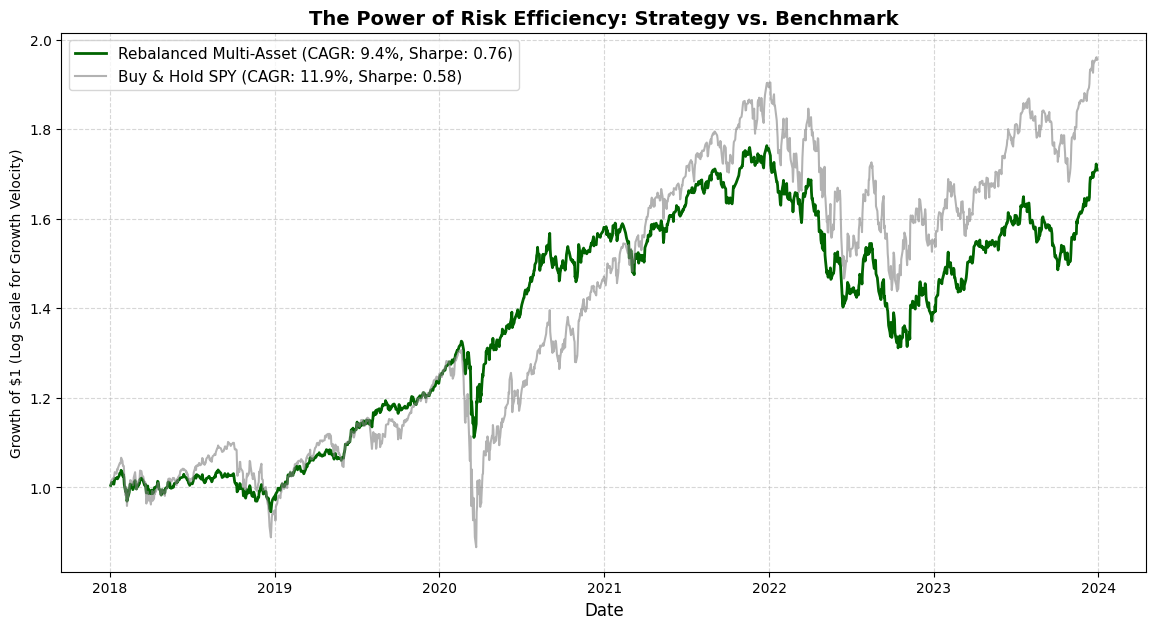

In [44]:
plt.figure(figsize=(14, 7))

plt.plot(portfolio_cum_net, label=f'Rebalanced Multi-Asset (CAGR: {strategy_cagr*100:.1f}%, Sharpe: {strategy_sharpe:.2f})', color='darkgreen', lw=2)
plt.plot(benchmark_cum, label=f'Buy & Hold SPY (CAGR: {benchmark_cagr*100:.1f}%, Sharpe: {benchmark_sharpe:.2f})', color='gray', alpha=0.6, lw=1.5)

plt.title('The Power of Risk Efficiency: Strategy vs. Benchmark', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Growth of $1 (Log Scale for Growth Velocity)')
plt.yscale('linear') 
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [45]:
#day17 
strategy_peaks = portfolio_cum_net.cummax()
benchmark_peaks = benchmark_cum.cummax()

strategy_dd_series = (portfolio_cum_net - strategy_peaks)/strategy_peaks
benchmark_dd_series = (benchmark_cum - benchmark_peaks)/benchmark_peaks

print(f"Strategy max daily drops percentage: {strategy_dd_series} ")
print(f"Benchmark max daily drops percentage: {benchmark_dd_series} ")

Strategy max daily drops percentage: Date
2018-01-03    0.000000
2018-01-04    0.000000
2018-01-05    0.000000
2018-01-08    0.000000
2018-01-09   -0.003867
                ...   
2023-12-22   -0.034611
2023-12-26   -0.029628
2023-12-27   -0.023193
2023-12-28   -0.026441
2023-12-29   -0.030849
Length: 1508, dtype: float64 
Benchmark max daily drops percentage: Date
2018-01-03    0.000000
2018-01-04    0.000000
2018-01-05    0.000000
2018-01-08    0.000000
2018-01-09    0.000000
                ...   
2023-12-22   -0.002506
2023-12-26    0.000000
2023-12-27    0.000000
2023-12-28    0.000000
2023-12-29   -0.002895
Name: SPY, Length: 1508, dtype: float64 


       DAY 17: COMPLETED RISK & RECOVERY METRICS  
Strategy Max Peak-to-Trough Drop:  -25.62%
Benchmark Max Peak-to-Trough Drop: -33.72%
Strategy Longest Streak Underwater:  505 trading days
Benchmark Longest Streak Underwater: 488 trading days


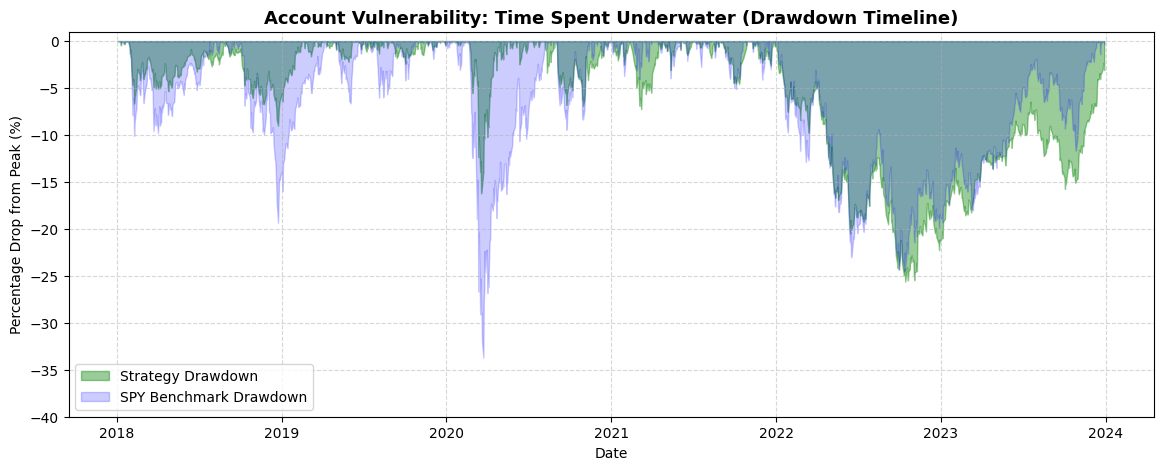

In [46]:
#seeing for how long max we will be underwater
def get_max_recovery_days(dd_series):
    # Create a boolean series: True if underwater, False if at a new peak
    underwater_mask = dd_series < 0
    
    streaks = underwater_mask.groupby((~underwater_mask).cumsum()).sum()
    return streaks.max()

strat_max_days_underwater = get_max_recovery_days(strategy_dd_series)
bench_max_days_underwater = get_max_recovery_days(benchmark_dd_series)

print("       DAY 17: COMPLETED RISK & RECOVERY METRICS  ")
print(f"Strategy Max Peak-to-Trough Drop:  {strategy_dd_series.min() * 100:.2f}%")
print(f"Benchmark Max Peak-to-Trough Drop: {benchmark_dd_series.min() * 100:.2f}%")
print(f"Strategy Longest Streak Underwater:  {strat_max_days_underwater} trading days")
print(f"Benchmark Longest Streak Underwater: {bench_max_days_underwater} trading days")

# Plotting the area chart
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Fill valleys downward from 0%
plt.fill_between(strategy_dd_series.index, strategy_dd_series * 100, 0, 
                 label='Strategy Drawdown', color='green', alpha=0.4)
plt.fill_between(benchmark_dd_series.index, benchmark_dd_series * 100, 0, 
                 label='SPY Benchmark Drawdown', color='blue', alpha=0.2)

# Chart adjustments
plt.title('Account Vulnerability: Time Spent Underwater (Drawdown Timeline)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Percentage Drop from Peak (%)')
plt.ylim(-40, 1) 
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower left')

plt.show()

In [47]:
#day 18 measuring effectiveness while lookking at the fixed return as well

TRADING_DAYS_PER_YEAR = 252
RISK_FREE_RATE_ANNUAL = 0.02

strategy_daily_returns = portfolio_cum_net.pct_change().dropna()
benchmark_daily_returns = benchmark_cum.pct_change().dropna()

strat_ann_return = strategy_daily_returns.mean()*TRADING_DAYS_PER_YEAR
bench_ann_return = benchmark_daily_returns.mean()*TRADING_DAYS_PER_YEAR

strat_total_vol = strategy_daily_returns.std()*np.sqrt(TRADING_DAYS_PER_YEAR)
bench_total_vol = benchmark_daily_returns.std()*np.sqrt(TRADING_DAYS_PER_YEAR)

strat_negative_returns = strategy_daily_returns[strategy_daily_returns<0]
bench_negative_returns = benchmark_daily_returns[benchmark_daily_returns<0]

strat_downside_vol = strat_negative_returns.std()*np.sqrt(TRADING_DAYS_PER_YEAR)
bench_downside_vol = bench_negative_returns.std()*np.sqrt(TRADING_DAYS_PER_YEAR)

strat_sharpe = (strat_ann_return - RISK_FREE_RATE_ANNUAL)/strat_total_vol
bench_sharpe = (bench_ann_return - RISK_FREE_RATE_ANNUAL)/bench_total_vol

strat_sortino = (strat_ann_return - RISK_FREE_RATE_ANNUAL)/strat_downside_vol
bench_sortino = (bench_ann_return - RISK_FREE_RATE_ANNUAL)/bench_downside_vol

print(f"Strategy Annualized Return:  {strat_ann_return * 100:.2f}%")
print(f"Benchmark Annualized Return: {bench_ann_return * 100:.2f}%")

print(f"Strategy Sharpe Ratio: {strat_sharpe:.2f}")
print(f"Benchmark Sharpe Ratio: {bench_sharpe:.2f}")

print(f"Strategy Sortino Ratio: {strat_sortino:.2f}")
print(f"Benchmark Sortino Ratio: {bench_sortino:.2f}")

Strategy Annualized Return:  9.65%
Benchmark Annualized Return: 13.20%
Strategy Sharpe Ratio: 0.62
Benchmark Sharpe Ratio: 0.55
Strategy Sortino Ratio: 0.82
Benchmark Sortino Ratio: 0.67


       DAY 19: SIMULATION ENGINE INITIALIZED      
Historical Daily Mean Return (mu): 0.0383%
Historical Daily Volatility (sigma): 0.7778%
--------------------------------------------------
Simulation Horizon: 252 trading days (1 Year)
Median Projected Ending Value: 1.09x
Mathematical Probability of Loss: 23.60%


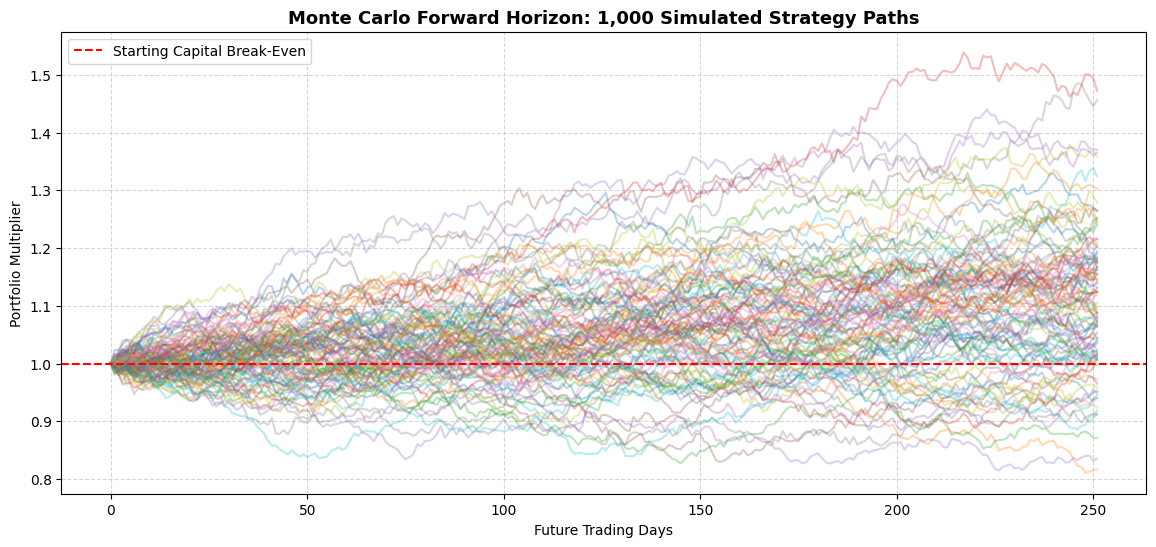

In [48]:
# ==============================================================================
# DAY 19: MONTE CARLO FUTURE SIMULATION ENGINE (PRODUCTION) gemini generated code which takes a normal shaped curve
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Constants
NUM_SIMULATIONS = 1000
FORECAST_DAYS = 252  # 1 trading year ahead
STARTING_VALUE = 1.0  # Normalizing starting portfolio value to 1.0 (or 100%)

# ------------------------------------------------------------------------------
# STEP 1: EXTRACT STATISTICAL INPUTS FROM PERCENT CHANGE SERIES
# ------------------------------------------------------------------------------
# We use the percent change series you generated on Day 18
mu = strategy_daily_returns.mean()
sigma = strategy_daily_returns.std()

print("==================================================")
print("       DAY 19: SIMULATION ENGINE INITIALIZED      ")
print("==================================================")
print(f"Historical Daily Mean Return (mu): {mu * 100:.4f}%")
print(f"Historical Daily Volatility (sigma): {sigma * 100:.4f}%")
print("--------------------------------------------------")

# ------------------------------------------------------------------------------
# STEP 2 & 3: SETUP MATRIX & SIMULATE GEOMETRIC BROWNIAN MOTION
# ------------------------------------------------------------------------------
# Create an empty matrix: rows = days, columns = individual simulation paths
sim_matrix = np.zeros((FORECAST_DAYS, NUM_SIMULATIONS))
sim_matrix[0] = STARTING_VALUE

# Vectorized simulation loop across all 1,000 paths simultaneously
for t in range(1, FORECAST_DAYS):
    # Draw 1,000 random shocks from standard normal distribution Z ~ N(0, 1)
    Z = np.random.normal(0, 1, NUM_SIMULATIONS)
    
    # Apply the GBM Formula: V_t = V_{t-1} * exp((mu - 0.5 * sigma^2) + sigma * Z)
    drift = mu - 0.5 * (sigma ** 2)
    shock = sigma * Z
    sim_matrix[t] = sim_matrix[t - 1] * np.exp(drift + shock)

# ------------------------------------------------------------------------------
# STEP 4: ANALYZE PREDICTIVE DISTRIBUTION & PROBABILITIES
# ------------------------------------------------------------------------------
# Extract final row values (the ending portfolio value for all 1,000 paths)
ending_values = sim_matrix[-1, :]

# Calculate probability of losing money (ending value < starting value of 1.0)
negative_paths = ending_values[ending_values < STARTING_VALUE]
prob_of_loss = (len(negative_paths) / NUM_SIMULATIONS) * 100

print(f"Simulation Horizon: {FORECAST_DAYS} trading days (1 Year)")
print(f"Median Projected Ending Value: {np.median(ending_values):.2f}x")
print(f"Mathematical Probability of Loss: {prob_of_loss:.2f}%")
print("==================================================")

# ------------------------------------------------------------------------------+
# VISUALIZE THE OUTCOMES
# ------------------------------------------------------------------------------
plt.figure(figsize=(14, 6))

# Plot the first 100 paths to keep chart legible
plt.plot(sim_matrix[:, :100], alpha=0.3)
plt.axhline(STARTING_VALUE, color='red', linestyle='--', linewidth=1.5, label='Starting Capital Break-Even')
plt.title(f'Monte Carlo Forward Horizon: 1,000 Simulated Strategy Paths', fontsize=13, fontweight='bold')
plt.xlabel('Future Trading Days')
plt.ylabel('Portfolio Multiplier')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')

plt.show()

 DAY 19: BOOTSTRAPPED SIMULATION INITIALIZED 
Total Historical Days Available to Sample: 1507
Historical Win Rate (Positive Days): 55.67%
Simulation Horizon: 252 training days (1 Year)
Median Projected Ending Value: 1.10x
Probability of Capital Loss: 24.00%
Probability of Positive Return: 76.00%


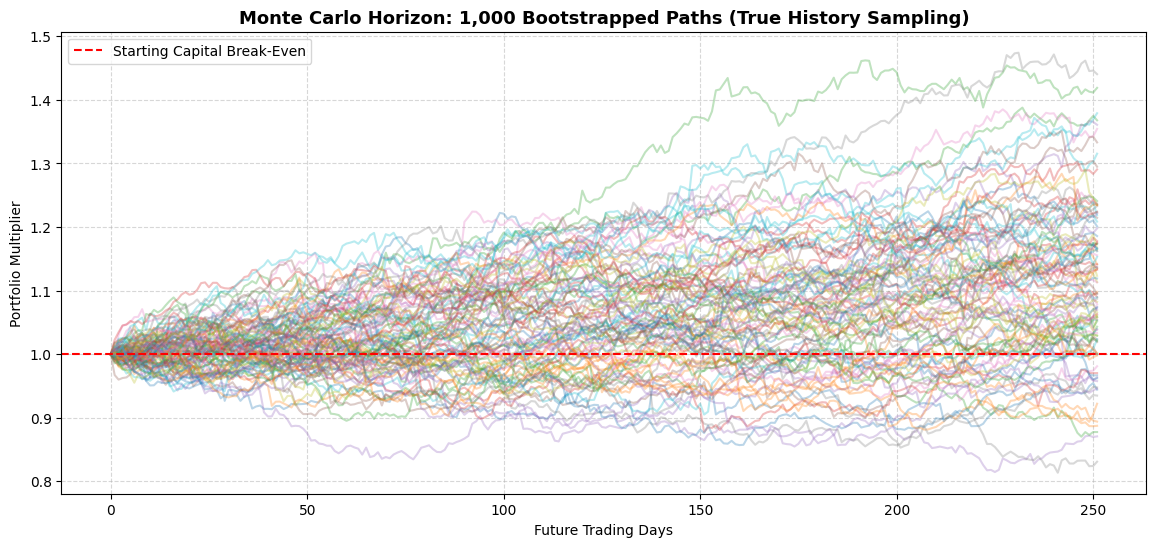

In [49]:
# DAY 19 (MODIFIED): MONTE CARLO FUTURE SIMULATION ENGINE (BOOTSTRAP METHOD) , I modified it by using historical data instead of a hypothetical normal bell curve
# also one important realisation is that the b
NUM_SIMULATIONS = 1000
FORECAST_DAYS = 252 # 1 trading year ahead
STARTING_VALUE = 1.0  # Normalizing starting portfolio value to 1.0 (or 100%)

# Ensure our historical returns series is clean and dropped of NaNs
historical_returns = strategy_daily_returns.dropna().values

print(" DAY 19: BOOTSTRAPPED SIMULATION INITIALIZED ")
print(f"Total Historical Days Available to Sample: {len(historical_returns)}")
print(f"Historical Win Rate (Positive Days): {(historical_returns > 0).mean() * 100:.2f}%")

# SETUP MATRIX & SIMULATE VIA HISTORICAL RESAMPLING
# Create empty matrix: rows = days, columns = paths
sim_matrix = np.zeros((FORECAST_DAYS, NUM_SIMULATIONS))
sim_matrix[0] = STARTING_VALUE

# Compounding loop across the timeline
for t in range(1, FORECAST_DAYS):
    # CRITICAL CHANGE: Instead of generating Z from a bell curve, 
    # we randomly select 1,000 actual daily percentages from your history
    sampled_returns = np.random.choice(historical_returns, size = NUM_SIMULATIONS)
    
    # Apply standard percentage compounding to yesterday's value: V_t = V_{t-1} * (1 + return)
    sim_matrix[t] = sim_matrix[t-1] * (1+sampled_returns)

# Extract the ending portfolio value for all 1,000 paths
ending_values = sim_matrix[-1, :]

# Calculate probability of losing money (ending value < starting value of 1.0)
negative_paths = ending_values[ending_values < STARTING_VALUE]
prob_of_loss = (len(negative_paths)/NUM_SIMULATIONS)*100

print(f"Simulation Horizon: {FORECAST_DAYS} training days (1 Year)")
print(f"Median Projected Ending Value: {np.median(ending_values):.2f}x")
print(f"Probability of Capital Loss: {prob_of_loss:.2f}%")
print(f"Probability of Positive Return: {100 - prob_of_loss:.2f}%")

plt.figure(figsize=(14, 6))

# Plot the first 100 paths to keep chart legible
plt.plot(sim_matrix[:, :100], alpha=0.3)
plt.axhline(STARTING_VALUE, color='red', linestyle='--', linewidth=1.5, label='Starting Capital Break-Even')
plt.title('Monte Carlo Horizon: 1,000 Bootstrapped Paths (True History Sampling)', fontsize=13, fontweight='bold')
plt.xlabel('Future Trading Days')
plt.ylabel('Portfolio Multiplier')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')

plt.show()

In [50]:
#ending_returns,confidence_level,alpha_percentile,var_95,worst_paths_returns
# checking the worst path returns, are you capable of handing it

ending_returns = (ending_values - STARTING_VALUE)*100

confidence_level = 0.95
alpha_percentile = (1-confidence_level)*100

var_95 = np.percentile(ending_returns, alpha_percentile)

worst_path_returns = ending_returns[ending_returns <= var_95]
cvar_95 = np.mean(worst_path_returns)

print(f"95% Value at Risk (VaR): {var_95:.2f}%")
print(f"95% Conditional Value at Risk (CVaR): {cvar_95:.2f}%")
print(f"-> There is a 95% chance your portfolio will not lose more than {abs(var_95):.2f}%")
print(f"-> If you hit the worst 5% tail event, your average loss will be {abs(cvar_95):.2f}%")

95% Value at Risk (VaR): -11.29%
95% Conditional Value at Risk (CVaR): -15.77%
-> There is a 95% chance your portfolio will not lose more than 11.29%
-> If you hit the worst 5% tail event, your average loss will be 15.77%


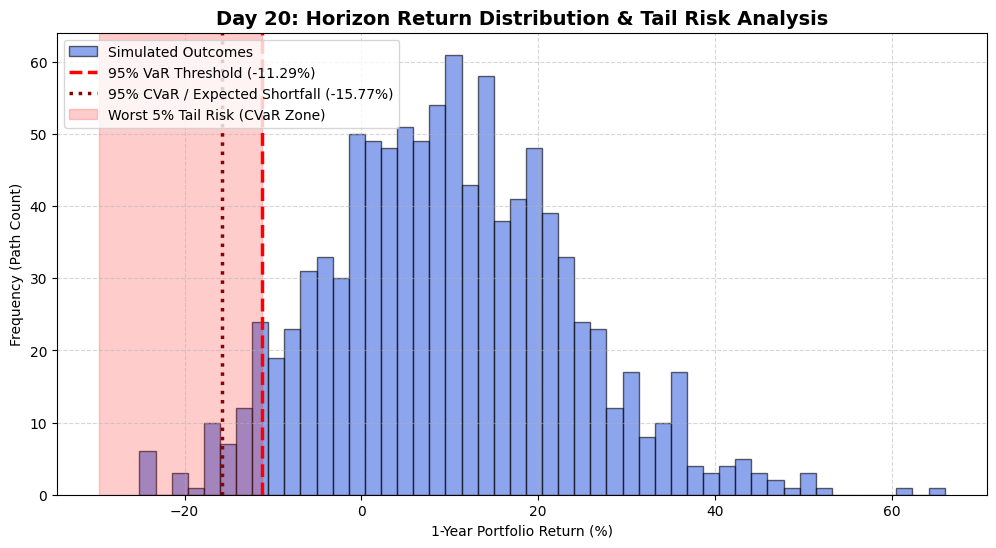

In [51]:
plt.figure(figsize=(12, 6))

# Plot the histogram of all 1,000 ending returns
plt.hist(ending_returns, bins=50, edgecolor='black', alpha=0.6, color='royalblue', label='Simulated Outcomes')

# Draw the VaR line (The Cliff Edge)
plt.axvline(var_95, color='red', linestyle='--', linewidth=2.5, 
            label=f'95% VaR Threshold ({var_95:.2f}%)')

# Draw the CVaR line (The Average Drop)
plt.axvline(cvar_95, color='darkred', linestyle=':', linewidth=2.5, 
            label=f'95% CVaR / Expected Shortfall ({cvar_95:.2f}%)')

# Highlight the worst 5% Tail Risk Zone
plt.axvspan(plt.xlim()[0], var_95, color='red', alpha=0.2, label='Worst 5% Tail Risk (CVaR Zone)')

plt.title('Day 20: Horizon Return Distribution & Tail Risk Analysis', fontsize=14, fontweight='bold')
plt.xlabel('1-Year Portfolio Return (%)')
plt.ylabel('Frequency (Path Count)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')

plt.show()